# Per-Class SM2RAIN Parameter Calibration

This notebook calibrates SM2RAIN parameters for each rainfall class separately.

**Approach:**
1. Read SMAP soil moisture data from NetCDF
2. Read rainfall classification data for SMAP grid points
3. For each class, use only the filtered dates for calibration
4. Resample temperature and precipitation to SMAP grid using nearest neighbor
5. Calibrate 4 parameters (Z*, Ks, lambda, Kc) for each class
6. Save results to JSON files

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import netCDF4 as nc
import xarray as xr
from pathlib import Path
from datetime import datetime, timedelta
import warnings
import os
import json
from scipy.spatial import cKDTree
from scipy.optimize import differential_evolution
import sys
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Add parent directory to path to import custom modules
sys.path.append(str(Path.cwd().parent))

print("Libraries imported successfully!")

Libraries imported successfully!


## Configuration

In [2]:

# File paths
SMAP_FILE = Path(r'G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc')
# ^ NASA SMAP Level-3 soil moisture product (SPL3SMP_E), clipped to the
#   validation region of interest (ROI). Contains AM/PM soil moisture
#   observations on the EASE-Grid at each overpass time.

CLASSIFICATION_FILE = Path(r'G:\SM2RAIN-irrigation_Final\calibration\SM_classes\SM_classes_ludhiana.csv')
# ^ CSV mapping each SMAP grid point (lat/lon) to one of the NUM_CLASSES
#   rainfall intensity classes. Generated by the pre-processing step that
#   bins historical rainfall totals at each location.

DATES_DIR = Path(r'G:\SM2RAIN-irrigation_Final\calibration\calib_dates_rainfall_filtered')
# ^ Directory containing one CSV per class (class_1_filtered_dates.csv …
#   class_5_filtered_dates.csv). Each CSV lists the SMAP observation dates
#   that fall within ±N days of a rainfall event for that class — these are
#   the windows used for calibration.

TEMP_FILE = Path(r'G:\SM2RAIN-irrigation_Final\data\temp_data\AgERA5_daily_mean_ludhiana.nc')
# ^ Gridded daily mean 2-m air temperature (°C) from the Copernicus
#   agERA5 dataset, merged into a single NetCDF covering the full
#   validation period. Used to compute PET via the Hargreaves method.

PRECIP_FILE = Path(r'G:\SM2RAIN-irrigation_Final\data\precipitation_data\GPM_IMERG_ludhiana_final_run.nc')
# ^ Daily precipitation (mm/day) from GPM IMERG Final Run, pre-processed
#   and merged for the validation region. Serves as the reference rainfall
#   that SM2RAIN parameters are calibrated against.

# Output directory
OUTPUT_DIR = Path(r'G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana')
# ^ Where calibration results are written:
#     class_<i>_calibration_results.json  – per-class optimised parameters
#     all_classes_calibration_results.json – combined results
#     all_classes_best_parameters.csv      – summary table
#     parameter_variation_by_class.png     – parameter bar charts
#     rmse_kge_comparison_by_class.png     – performance comparison plots

# Output directory
# OUTPUT_DIR = Path(r'G:\sm2rain-irrigation\calibration\per_class_results_ludhiana')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# SM2RAIN configuration
T_EXPONENTIAL_FILTER = 5.0  # days
FILL_VALUE = -9999.0
SM_SOURCE = 'BOTH'  # 'AM', 'PM', or 'BOTH'

# Calibration mode
USE_AGGREGATED_WINDOWS = True  # True: aggregate over 5-day windows, False: use daily data

# Objective function: 'KGE' (Kling-Gupta Efficiency) or 'RMSE' (Root Mean Square Error)
# KGE: maximized (range -inf to 1.0, perfect = 1.0)  --> optimizer minimizes (1 - KGE)
# RMSE: minimized (range 0 to inf, perfect = 0.0)    --> optimizer minimizes RMSE directly
OBJECTIVE_FUNCTION = 'KGE'  # Switch here to change the objective function globally

# Calibration strategy
# False → per-point: each station is calibrated independently with its own events,
#          then the station with the best score is selected for the class.
#          Optimizer sees: N_events  data points per run  (e.g.  25 events)
#
# True  → pooled: ALL events from ALL stations in the class are merged into one
#          dataset and a single optimization is run for the whole class.
#          Optimizer sees: N_stations × N_events  data points  (e.g. 25×25 = 625)
POOLED_CALIBRATION = False  # Switch here

# Number of classes
NUM_CLASSES = 5

print("Configuration loaded:")
print(f"  SMAP file: {SMAP_FILE}")
print(f"  Classification file: {CLASSIFICATION_FILE}")
print(f"  Dates directory: {DATES_DIR}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  T filter: {T_EXPONENTIAL_FILTER} days")
print(f"  Number of classes: {NUM_CLASSES}")
print(f"  Calibration mode: {'AGGREGATED 5-day windows' if USE_AGGREGATED_WINDOWS else 'DAILY data'}")
print(f"  Objective function: {OBJECTIVE_FUNCTION}")
print(f"  Calibration strategy: {'POOLED (all stations × all events)' if POOLED_CALIBRATION else 'PER-POINT (best station selected)'}")


Configuration loaded:
  SMAP file: G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc
  Classification file: G:\SM2RAIN-irrigation_Final\calibration\SM_classes\SM_classes_ludhiana.csv
  Dates directory: G:\SM2RAIN-irrigation_Final\calibration\calib_dates_rainfall_filtered
  Output directory: G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana
  T filter: 5.0 days
  Number of classes: 5
  Calibration mode: AGGREGATED 5-day windows
  Objective function: KGE
  Calibration strategy: PER-POINT (best station selected)


## 1. Load SMAP Soil Moisture Data

In [3]:
def load_smap_data(smap_file, sm_source='BOTH', fill_value=-9999.0):
    """
    Load SMAP soil moisture data from NetCDF file.
    Based on SPL3SMP_reader.ipynb
    """
    print(f"Loading SMAP data from: {smap_file}")
    
    # Open NetCDF file
    ds = nc.Dataset(smap_file, 'r')
    
    # Read variables
    time_j2000 = ds.variables['time'][:]
    epoch = datetime(2000, 1, 1)
    time_dt = np.array([epoch + timedelta(seconds=float(t)) for t in time_j2000])
    
    latitude = ds.variables['latitude'][:]
    longitude = ds.variables['longitude'][:]
    soil_moisture_am = ds.variables['soil_moisture_am'][:]
    soil_moisture_pm = ds.variables['soil_moisture_pm'][:]
    
    ds.close()
    
    # Create DataFrame
    df = pd.DataFrame({
        'time': time_dt,
        'latitude': latitude,
        'longitude': longitude,
        'soil_moisture_am': soil_moisture_am,
        'soil_moisture_pm': soil_moisture_pm
    })
    
    # Filter out fill values
    df = df[(df['latitude'] != fill_value) & (df['longitude'] != fill_value)]
    df = df[(df['soil_moisture_am'] != fill_value) | (df['soil_moisture_pm'] != fill_value)]
    
    # Create combined soil moisture column
    if sm_source == 'AM':
        df['soil_moisture'] = df['soil_moisture_am'].replace(fill_value, np.nan)
    elif sm_source == 'PM':
        df['soil_moisture'] = df['soil_moisture_pm'].replace(fill_value, np.nan)
    elif sm_source == 'BOTH':
        sm_am = df['soil_moisture_am'].replace(fill_value, np.nan)
        sm_pm = df['soil_moisture_pm'].replace(fill_value, np.nan)
        df['soil_moisture'] = np.nanmean([sm_am, sm_pm], axis=0)
    
    # Remove NaN values
    df = df.dropna(subset=['soil_moisture'])
    
    # Convert time to datetime
    df['date'] = pd.to_datetime(df['time']).dt.date
    
    print(f"  Loaded {len(df):,} valid observations")
    print(f"  Date range: {df['time'].min()} to {df['time'].max()}")
    print(f"  Unique locations: {df.groupby(['latitude', 'longitude']).ngroups}")
    print(f"  Lat range: {df['latitude'].min():.4f} to {df['latitude'].max():.4f}")
    print(f"  Lon range: {df['longitude'].min():.4f} to {df['longitude'].max():.4f}")
    
    return df

# Load SMAP data
smap_df = load_smap_data(SMAP_FILE, SM_SOURCE, FILL_VALUE)
print("\nFirst few rows:")
print(smap_df.head())

Loading SMAP data from: G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc
  Loaded 288,684 valid observations
  Date range: 2015-04-03 00:00:00 to 2025-12-31 00:00:00
  Unique locations: 156
  Lat range: 30.0269 to 31.0071
  Lon range: 75.0156 to 76.0425

First few rows:
        time   latitude  longitude  soil_moisture_am  soil_moisture_pm  \
0 2015-04-03  31.007128  75.015564          0.202547               NaN   
1 2015-04-03  31.007128  75.108925          0.216642               NaN   
2 2015-04-03  31.007128  75.202286          0.195568               NaN   
3 2015-04-03  31.007128  75.295647          0.180963               NaN   
4 2015-04-03  31.007128  75.389008          0.182054               NaN   

   soil_moisture        date  
0       0.202547  2015-04-03  
1       0.216642  2015-04-03  
2       0.195568  2015-04-03  
3       0.180963  2015-04-03  
4       0.182054  2015-04-03  


## 2. Load Classification Data

In [4]:
# Load classification CSV
classification_df = pd.read_csv(CLASSIFICATION_FILE)
print(f"Classification data loaded: {len(classification_df)} records")
print(f"Rainfall classes: {sorted(classification_df['rainfall_class'].unique())}")
print(f"\nClass distribution:")
print(classification_df['rainfall_class'].value_counts().sort_index())
print(f"\nFirst few rows:")
print(classification_df.head(10))

Classification data loaded: 156 records
Rainfall classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Class distribution:
rainfall_class
1    25
2    16
3    42
4    41
5    32
Name: count, dtype: int64

First few rows:
    latitude  longitude  rainfall_class  grid_cell_index
0  30.026932  75.015564               1               13
1  30.026932  75.108925               1               14
2  30.026932  75.202286               1               15
3  30.026932  75.295650               1               15
4  30.026932  75.389010               1               16
5  30.026932  75.482370               2               17
6  30.026932  75.575730               3               18
7  30.026932  75.669090               3               19
8  30.026932  75.762450               3               20
9  30.026932  75.855810               3               21


## 3. Load Filtered Dates for Each Class

In [5]:
# Load filtered dates for each class
# Supports two filename conventions used by different upstream notebooks:
#   calib_dates_ludhiana/           →  class_{i}_calib_dates.csv
#   calib_dates_rainfall_filtered/  →  class_{i}_filtered_dates.csv
class_dates = {}
class_event_info = {}  # Store full event information for aggregation

# Candidate filename patterns tried in order
FILENAME_PATTERNS = [
    'class_{i}_filtered_dates.csv',   # 4-1_SMAP_rainfall_filter output
    'class_{i}_calib_dates.csv',      # 3_SMAP_calib_dates_per_class output
]

for class_id in range(1, NUM_CLASSES + 1):
    # Find the first matching file for this class
    date_file = None
    for pattern in FILENAME_PATTERNS:
        candidate = DATES_DIR / pattern.format(i=class_id)
        if candidate.exists():
            date_file = candidate
            break

    if date_file is None:
        print(f"WARNING: No date file found for class {class_id} in {DATES_DIR}")
        print(f"  Tried: {[DATES_DIR / p.format(i=class_id) for p in FILENAME_PATTERNS]}")
        continue

    dates_df = pd.read_csv(date_file)
    dates_df['date'] = pd.to_datetime(dates_df['date']).dt.date
    dates_df['event_date'] = pd.to_datetime(dates_df['event_date']).dt.date
    class_dates[class_id] = dates_df['date'].unique()
    class_event_info[class_id] = dates_df  # Store full dataframe
    print(f"Class {class_id}: {len(class_dates[class_id])} dates loaded "
          f"({dates_df['event_date'].nunique()} events)  [{date_file.name}]")

print(f"\nTotal classes with dates: {len(class_dates)}")
print(f"Source directory: {DATES_DIR}")


Class 1: 796 dates loaded (122 events)  [class_1_filtered_dates.csv]
Class 2: 834 dates loaded (124 events)  [class_2_filtered_dates.csv]
Class 3: 862 dates loaded (130 events)  [class_3_filtered_dates.csv]
Class 4: 806 dates loaded (121 events)  [class_4_filtered_dates.csv]
Class 5: 997 dates loaded (149 events)  [class_5_filtered_dates.csv]

Total classes with dates: 5
Source directory: G:\SM2RAIN-irrigation_Final\calibration\calib_dates_rainfall_filtered


## 4. Load Temperature and Precipitation Data

In [6]:
def load_netcdf_gridded_data(file_path, var_name=None):
    """
    Load gridded NetCDF data (temperature or precipitation).

    Strategy:
    1. Open with decode_times=True (works for standard CF-convention time).
    2. If all resulting dates are clearly wrong (year < 1980 after conversion),
       reopen with decode_times=False and use an explicit 'date' data variable
       when available (byte-string format DD-MM-YYYY, as used by GPM IMERG).
    """
    print(f"Loading data from: {file_path}")

    def _build_df(ds, var_name_inner):
        """Core helper: dataset → flat DataFrame."""
        data = ds[var_name_inner]
        lat_names  = ['lat', 'latitude', 'y']
        lon_names  = ['lon', 'longitude', 'x']
        time_names = ['time', 'date']
        lat_dim  = next((d for d in data.dims if d in lat_names),  None)
        lon_dim  = next((d for d in data.dims if d in lon_names),  None)
        time_dim = next((d for d in data.dims if d in time_names), None)
        if not all([lat_dim, lon_dim, time_dim]):
            raise ValueError("Could not identify lat/lon/time dimensions")
        df = data.to_dataframe().reset_index()
        df = df.rename(columns={
            lat_dim:        'lat',
            lon_dim:        'lon',
            time_dim:       'time',
            var_name_inner: 'value'
        })
        return df

    # ── Pass 1: standard CF decoding ────────────────────────────────────────
    ds = xr.open_dataset(file_path, decode_times=True)

    # Auto-detect variable name
    if var_name is None:
        candidates = [
            'Temperature_Air_2m_Mean_24h', 'temperature', 'temp', 't2m', 'tas',
            'precipitation', 'precip', 'tp', 'pr', 'precipitationCal',
        ]
        var_name = next((v for v in candidates if v in ds.variables), None)
    if var_name is None:
        raise ValueError(f"Could not auto-detect variable name in {file_path}")
    print(f"  Using variable: {var_name}")

    df = _build_df(ds, var_name)

    # Convert time column to datetime
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'], errors='coerce')

    df = df.dropna(subset=['time'])

    # Check whether the decoded dates look sensible (year >= 1980)
    valid_years = (df['time'].dt.year >= 1980).sum() if len(df) else 0
    dates_ok = valid_years > 0

    # ── Pass 2: fallback for files with no CF time units ────────────────────
    if not dates_ok:
        print(f"  CF time decode failed (all dates < 1980); trying 'date' variable fallback...")
        ds.close()
        ds = xr.open_dataset(file_path, decode_times=False)
        df = _build_df(ds, var_name)

        if 'date' in ds.data_vars:
            raw_dates = ds['date'].values
            parsed_dates = []
            for d in raw_dates:
                if isinstance(d, (bytes, np.bytes_)):
                    d = d.decode('utf-8')
                try:
                    parsed_dates.append(pd.to_datetime(d, dayfirst=True))
                except Exception:
                    parsed_dates.append(pd.NaT)
            time_map = {i: parsed_dates[i] for i in range(len(parsed_dates))}
            df['time'] = df['time'].map(time_map)
            print(f"  Time decoded via 'date' variable (DD-MM-YYYY).")
        else:
            df['time'] = pd.to_datetime(df['time'], errors='coerce')
            print(f"  WARNING: no 'date' fallback found; dates may be incorrect.")

        df = df.dropna(subset=['time'])

    df['date'] = df['time'].dt.date

    print(f"  Shape: {len(df)} records")
    print(f"  Unique locations: {df.groupby(['lat', 'lon']).ngroups}")
    print(f"  Date range: {df['time'].min()} to {df['time'].max()}")

    return df, ds

# Load temperature data
temp_df, temp_ds = load_netcdf_gridded_data(TEMP_FILE)
temp_df['value'] = temp_df['value'] - 273.15
print("\nTemperature data loaded")

# Load precipitation data
precip_df, precip_ds = load_netcdf_gridded_data(PRECIP_FILE)
print("\nPrecipitation data loaded")


Loading data from: G:\SM2RAIN-irrigation_Final\data\temp_data\AgERA5_daily_mean_ludhiana.nc
  Using variable: Temperature_Air_2m_Mean_24h
  Shape: 1149137 records
  Unique locations: 121
  Date range: 2000-01-01 00:00:00 to 2025-12-31 00:00:00

Temperature data loaded
Loading data from: G:\SM2RAIN-irrigation_Final\data\precipitation_data\GPM_IMERG_ludhiana_final_run.nc
  Using variable: precipitation
  CF time decode failed (all dates < 1980); trying 'date' variable fallback...
  Time decoded via 'date' variable (DD-MM-YYYY).
  Shape: 578592 records
  Unique locations: 144
  Date range: 2015-01-01 00:00:00 to 2025-12-31 00:00:00

Precipitation data loaded


## 5. Spatial Resampling - Nearest Neighbor to SMAP Grid

In [7]:
def resample_to_smap_grid(source_df, smap_coords, value_col='value'):
    """
    Resample source data (temperature or precipitation) to SMAP grid using nearest neighbor.
    
    Parameters:
    -----------
    source_df : DataFrame
        Source data with columns: lat, lon, date, value
    smap_coords : DataFrame
        SMAP coordinates with columns: latitude, longitude
    value_col : str
        Name of the value column in source_df
    
    Returns:
    --------
    DataFrame with resampled data matched to SMAP grid
    """
    print("\nResampling to SMAP grid using nearest neighbor...")
    
    # Get unique source coordinates
    source_coords = source_df[['lat', 'lon']].drop_duplicates().values
    smap_coords_array = smap_coords[['latitude', 'longitude']].values
    
    print(f"  Source grid points: {len(source_coords)}")
    print(f"  Target SMAP grid points: {len(smap_coords_array)}")
    
    # Build KD-tree for source coordinates
    tree = cKDTree(source_coords)
    
    # Find nearest neighbors for each SMAP point
    distances, indices = tree.query(smap_coords_array)
    
    print(f"  Mean distance to nearest neighbor: {distances.mean():.4f} degrees")
    print(f"  Max distance to nearest neighbor: {distances.max():.4f} degrees")
    
    # Create mapping dictionary
    mapping = {}
    for i, (smap_lat, smap_lon) in enumerate(smap_coords_array):
        nearest_idx = indices[i]
        source_lat, source_lon = source_coords[nearest_idx]
        mapping[(smap_lat, smap_lon)] = (source_lat, source_lon)
    
    # Apply mapping to create resampled dataframe
    resampled_data = []
    
    for (smap_lat, smap_lon), (source_lat, source_lon) in mapping.items():
        # Get all time series data for this source point
        subset = source_df[
            (source_df['lat'] == source_lat) & 
            (source_df['lon'] == source_lon)
        ].copy()
        
        if len(subset) > 0:
            subset['smap_lat'] = smap_lat
            subset['smap_lon'] = smap_lon
            resampled_data.append(subset)
    
    resampled_df = pd.concat(resampled_data, ignore_index=True)
    
    print(f"  Resampled data records: {len(resampled_df)}")
    
    return resampled_df

# Get unique SMAP coordinates
smap_coords = smap_df[['latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
print(f"\nUnique SMAP grid points: {len(smap_coords)}")

# Resample temperature to SMAP grid
temp_resampled = resample_to_smap_grid(temp_df, smap_coords)

# Resample precipitation to SMAP grid
precip_resampled = resample_to_smap_grid(precip_df, smap_coords)

print("\nResampling complete!")


Unique SMAP grid points: 156

Resampling to SMAP grid using nearest neighbor...
  Source grid points: 121
  Target SMAP grid points: 156
  Mean distance to nearest neighbor: 0.0369 degrees
  Max distance to nearest neighbor: 0.0683 degrees
  Resampled data records: 1481532

Resampling to SMAP grid using nearest neighbor...
  Source grid points: 144
  Target SMAP grid points: 156
  Mean distance to nearest neighbor: 0.0400 degrees
  Max distance to nearest neighbor: 0.0674 degrees
  Resampled data records: 626808

Resampling complete!


## 6. SM2RAIN Functions

In [8]:

def normalize_soil_moisture(sm_series, sm_min=None, sm_max=None):
    """
    Normalize soil moisture to relative wetness [0, 1].

    If sm_min / sm_max are provided (computed from the full time series for
    that station), those are used so the scaling reflects the true residual
    moisture / saturation range.  Otherwise the min/max of the passed series
    is used as a fallback.
    """
    if sm_min is None:
        sm_min = sm_series.min()
    if sm_max is None:
        sm_max = sm_series.max()

    if sm_max - sm_min < 1e-6:
        return pd.Series(np.ones(len(sm_series)) * 0.5, index=sm_series.index)

    sm_rel = (sm_series - sm_min) / (sm_max - sm_min)
    # Clip to [0, 1] in case calibration-period values fall slightly outside
    # the global range due to measurement noise
    sm_rel = sm_rel.clip(0.0, 1.0)
    return sm_rel


def exponential_filter(sm_series, T):
    """
    Apply exponential smoothing filter.
    """
    alpha = 2.0 / (T + 1.0)
    sm_filtered = sm_series.ewm(alpha=alpha, adjust=False).mean()
    return sm_filtered


def compute_sm2rain_rainfall(sm_rel, Zstar, Ks, lam, T):
    """
    Compute SM2RAIN-estimated rainfall.
    
    Parameters:
    -----------
    sm_rel : pd.Series
        Relative soil moisture [0, 1]
    Zstar : float
        Effective soil depth (mm)
    Ks : float
        Saturated hydraulic conductivity (mm/day)
    lam : float
        Shape parameter
    T : float
        Time constant for exponential filter (days)
    
    Returns:
    --------
    pd.Series : Estimated rainfall (mm/day)
    """
    # Apply exponential filter
    sm_filtered = exponential_filter(sm_rel, T)
    
    # Compute time derivative of filtered soil moisture
    dsm_dt = sm_filtered.diff() / 1.0  # Daily data
    dsm_dt.iloc[0] = 0
    
    # Compute drainage term
    drainage = Ks * (sm_filtered ** lam)
    
    # SM2RAIN equation: P = Z* * dS/dt + Ks * S^lambda
    P_estimated = Zstar * dsm_dt + drainage
    
    # Clip negative values
    P_estimated = P_estimated.clip(lower=0)
    
    return P_estimated


def compute_pet_hargreaves(temp_series, lat):
    """
    Compute potential evapotranspiration using Hargreaves method.
    Simplified version (requires only temperature).
    """
    # Simple approximation: PET ~ 0.0023 * (T_mean + 17.8) * Ra
    # For simplicity, use a constant Ra approximation
    Ra = 15.0  # Extraterrestrial radiation approximation (MJ/m²/day)
    
    PET = 0.0023 * (temp_series + 17.8) * Ra
    return PET.clip(lower=0)


def sm2rain_with_et(sm_rel, temp_series, lat, Zstar, Ks, lam, Kc, T):
    """
    SM2RAIN with evapotranspiration correction.
    
    Total water input = P_estimated + Kc * PET
    """
    # Compute SM2RAIN rainfall
    P_sm2rain = compute_sm2rain_rainfall(sm_rel, Zstar, Ks, lam, T)
    
    # Compute PET
    PET = compute_pet_hargreaves(temp_series, lat)
    
    # Total water input
    total_water_input = P_sm2rain + Kc * PET
    
    return total_water_input, P_sm2rain, PET


def calculate_kge(simulated, observed):
    """
    Calculate the Kling-Gupta Efficiency (KGE).
    
    KGE = 1 - sqrt((r-1)^2 + (beta-1)^2 + (gamma-1)^2)
    where:
        r     = Pearson correlation coefficient
        beta  = mean_sim / mean_obs  (bias ratio)
        gamma = CV_sim / CV_obs      (variability ratio)
    
    Perfect score = 1.0
    Returns -9999.0 if insufficient valid data.
    """
    sim = np.asarray(simulated, dtype=float)
    obs = np.asarray(observed, dtype=float)
    
    # Mask out NaNs
    valid = ~np.isnan(sim) & ~np.isnan(obs)
    sim = sim[valid]
    obs = obs[valid]
    
    if len(sim) < 2:
        return -9999.0
    
    # Pearson correlation (r)
    r = np.corrcoef(sim, obs)[0, 1]
    if np.isnan(r):
        return -9999.0
    
    mean_obs = np.mean(obs)
    mean_sim = np.mean(sim)
    
    # Bias ratio (beta)
    beta = mean_sim / (mean_obs + 1e-6)
    
    # Variability ratio (gamma = CV_sim / CV_obs)
    cv_sim = np.std(sim) / (mean_sim + 1e-6)
    cv_obs = np.std(obs) / (mean_obs + 1e-6)
    gamma = cv_sim / (cv_obs + 1e-6)
    
    kge = 1.0 - np.sqrt((r - 1.0) ** 2 + (beta - 1.0) ** 2 + (gamma - 1.0) ** 2)
    return kge


def compute_objective(simulated, observed, objective='KGE'):
    """
    Compute calibration objective to be MINIMIZED by the optimizer.
    
    Parameters:
    -----------
    simulated : array-like
        Model-estimated values
    observed : array-like
        Reference / observed values
    objective : str
        'KGE'  -> returns (1 - KGE);  perfect = 0, worse > 0
        'RMSE' -> returns RMSE;       perfect = 0, worse > 0
    
    Returns:
    --------
    float : scalar loss value (lower is better)
    """
    sim = np.asarray(simulated, dtype=float)
    obs = np.asarray(observed, dtype=float)
    
    if objective == 'KGE':
        kge = calculate_kge(sim, obs)
        if kge == -9999.0:
            return 1e6
        return 1.0 - kge  # Minimize (1 - KGE); perfect KGE=1 -> loss=0
    else:  # RMSE
        return np.sqrt(np.mean((sim - obs) ** 2))


print("SM2RAIN functions defined (KGE and RMSE objective supported).")


SM2RAIN functions defined (KGE and RMSE objective supported).


## 7. Calibration Function

In [9]:

def calibrate_sm2rain_parameters(sm_series, temp_series, rain_reference, lat, T_filter,
                                  sm_global_min=None, sm_global_max=None):
    """
    Calibrate SM2RAIN parameters using differential evolution.
    
    Parameters:
    -----------
    sm_series : pd.Series
        Soil moisture time series (calibration period only)
    temp_series : pd.Series
        Temperature time series (aligned with sm_series)
    rain_reference : pd.Series
        Reference rainfall for calibration (aligned with sm_series)
    lat : float
        Latitude of the location
    T_filter : float
        Exponential filter time constant
    sm_global_min : float, optional
        S_min from the FULL time series for this station (residual / wilting point).
        If provided, normalization uses this instead of the calibration-period min.
    sm_global_max : float, optional
        S_max from the FULL time series for this station (saturation / max porosity).
        If provided, normalization uses this instead of the calibration-period max.
    
    Returns:
    --------
    dict : Calibrated parameters and objective score
    """
    # Normalize soil moisture using full-series min/max so that
    # S_relative = (S_raw - S_min_global) / (S_max_global - S_min_global)
    sm_rel = normalize_soil_moisture(sm_series, sm_global_min, sm_global_max)
    
    # Define objective function (minimized by optimizer)
    def objective(params):
        Zstar, Ks, lam, Kc = params
        
        try:
            # Compute SM2RAIN rainfall with ET
            total_water_input, _, _ = sm2rain_with_et(
                sm_rel, temp_series, lat, Zstar, Ks, lam, Kc, T_filter
            )
            
            # Use globally configured objective function
            return compute_objective(
                total_water_input.values, rain_reference.values, OBJECTIVE_FUNCTION
            )
        except Exception:
            return 1e6  # Return large penalty if computation fails
    
    # Parameter bounds
    bounds = [
        (0.001, 100.0),    # Zstar (mm)
        (0.001, 50.0),     # Ks (mm/day)
        (-20, 20.0),       # lambda
        (0.001, 25.0)      # Kc
    ]
    
    # Run differential evolution
    result = differential_evolution(
        objective,
        bounds,
        strategy='best1bin',    # Standard aggressive strategy
        mutation=(0.5, 1.5),    # High exploration
        recombination=0.9,      # High trait mixing
        seed=83,
        maxiter=5000,           # Increased to allow deep search
        popsize=30,            # MASSIVE initial search grid
        tol=1e-6,               # Relentless precision
        atol=1e-6,              # Relentless precision
        updating='deferred',    # Better for avoiding local minima
        workers=1 
    )
    
    Zstar_opt, Ks_opt, lam_opt, Kc_opt = result.x
    loss_opt = result.fun  # (1 - KGE) or RMSE depending on OBJECTIVE_FUNCTION
    
    # Compute both metrics for reporting
    total_water_input, _, _ = sm2rain_with_et(
        sm_rel, temp_series, lat, Zstar_opt, Ks_opt, lam_opt, Kc_opt, T_filter
    )
    rmse_final = np.sqrt(np.mean((total_water_input.values - rain_reference.values) ** 2))
    kge_final  = calculate_kge(total_water_input.values, rain_reference.values)
    
    return {
        'Zstar': Zstar_opt,
        'Ks': Ks_opt,
        'lam': lam_opt,
        'Kc': Kc_opt,
        'rmse': rmse_final,
        'kge': kge_final,
        'loss': loss_opt,          # The minimized objective value
        'objective_fn': OBJECTIVE_FUNCTION,
        'success': result.success
    }

print("Calibration function defined.")


def calibrate_sm2rain_aggregated(event_data_list, lat, T_filter,
                                  sm_global_min=None, sm_global_max=None):
    """
    Calibrate SM2RAIN parameters using aggregated 5-day windows.
    
    Parameters:
    -----------
    event_data_list : list of dicts
        Each dict contains aggregated data for one event:
        - sm_start: soil moisture at start of window
        - sm_end: soil moisture at end of window
        - rain_total: total rainfall over window
        - temp_mean: mean temperature over window
        - window_days: number of days in window
    lat : float
        Latitude of the location
    T_filter : float
        Exponential filter time constant
    sm_global_min : float, optional
        S_min from the FULL time series for this station (residual / wilting point).
        If provided, normalization uses this instead of the event-period min.
    sm_global_max : float, optional
        S_max from the FULL time series for this station (saturation / max porosity).
        If provided, normalization uses this instead of the event-period max.
    
    Returns:
    --------
    dict : Calibrated parameters and objective score
    """
    # Extract aggregated values
    rain_totals = np.array([evt['rain_total'] for evt in event_data_list])
    temp_means  = np.array([evt['temp_mean']  for evt in event_data_list])
    window_days = np.array([evt['window_days'] for evt in event_data_list])
    
    # -----------------------------------------------------------------------
    # Determine S_min / S_max for normalisation
    # Priority: global stats from the full time series (passed in as args).
    # Fallback: min/max over all SM values present in this event list.
    # -----------------------------------------------------------------------
    if sm_global_min is not None and sm_global_max is not None:
        sm_min = sm_global_min
        sm_max = sm_global_max
    else:
        all_sm_values = np.concatenate([[evt['sm_start'], evt['sm_end']] for evt in event_data_list])
        sm_min = all_sm_values.min()
        sm_max = all_sm_values.max()
    
    sm_range = sm_max - sm_min if (sm_max - sm_min) > 1e-6 else 1.0

    # Normalise: S_rel = (S_raw - S_min) / (S_max - S_min), clipped to [0, 1]
    sm_rel_start = np.clip(
        np.array([(evt['sm_start'] - sm_min) / sm_range for evt in event_data_list]), 0.0, 1.0
    )
    sm_rel_end = np.clip(
        np.array([(evt['sm_end'] - sm_min) / sm_range for evt in event_data_list]), 0.0, 1.0
    )
    
    # Define objective function (minimized by optimizer)
    def objective(params):
        Zstar, Ks, lam, Kc = params
        
        try:
            estimated_inputs = []
            
            for i in range(len(event_data_list)):
                # SM2RAIN water balance over window
                # P_total = Zstar * (SM_end - SM_start) + Ks * window_days * SM_mean^lambda + Kc * PET_mean * window_days
                
                sm_change_rel = sm_rel_end[i] - sm_rel_start[i]
                sm_mean_rel = (sm_rel_start[i] + sm_rel_end[i]) / 2.0
                
                # Compute PET for mean temperature
                Ra = 15.0  # Extraterrestrial radiation approximation
                PET_daily = max(0.0, 0.0023 * (temp_means[i] + 17.8) * Ra)
                
                # Total water input estimation
                # Note: storage term uses sm_range to convert dimensionless dS back to mm
                storage_term  = Zstar * sm_range * sm_change_rel
                drainage_term = Ks * window_days[i] * (sm_mean_rel ** lam)
                et_term       = Kc * PET_daily * window_days[i]
                
                total_input = storage_term + drainage_term + et_term
                estimated_inputs.append(max(0.0, total_input))
            
            estimated_inputs = np.array(estimated_inputs)
            
            # Use globally configured objective function
            return compute_objective(estimated_inputs, rain_totals, OBJECTIVE_FUNCTION)
        except Exception:
            return 1e6
    
    # Parameter bounds
    bounds = [
        (10.0, 250.0),    # Zstar (mm)
        (10, 250.0),      # Ks (mm/day)
        (3.0, 15.0),       # lambda
        (0, 1.5)         # Kc
    ]
    
    # Run differential evolution
    result = differential_evolution(
        objective,
        bounds,
        strategy='best1bin',    # Standard aggressive strategy
        mutation=(0.5, 1.5),    # High exploration
        recombination=0.9,      # High trait mixing
        seed=83,
        maxiter=5000,           # Increased to allow deep search
        popsize=30,            # MASSIVE initial search grid
        tol=1e-6,               # Relentless precision
        atol=1e-6,              # Relentless precision
        updating='deferred',    # Better for avoiding local minima
        workers=1 
    )
    
    Zstar_opt, Ks_opt, lam_opt, Kc_opt = result.x
    loss_opt = result.fun  # (1 - KGE) or RMSE depending on OBJECTIVE_FUNCTION
    
    # Compute both metrics for reporting using optimal parameters
    estimated_inputs = []
    for i in range(len(event_data_list)):
        sm_change_rel = sm_rel_end[i] - sm_rel_start[i]
        sm_mean_rel   = (sm_rel_start[i] + sm_rel_end[i]) / 2.0
        Ra = 15.0
        PET_daily     = max(0.0, 0.0023 * (temp_means[i] + 17.8) * Ra)
        storage_term  = Zstar_opt * sm_range * sm_change_rel
        drainage_term = Ks_opt * window_days[i] * (sm_mean_rel ** lam_opt)
        et_term       = Kc_opt * PET_daily * window_days[i]
        estimated_inputs.append(max(0.0, storage_term + drainage_term + et_term))
    estimated_inputs = np.array(estimated_inputs)
    
    rmse_final = np.sqrt(np.mean((estimated_inputs - rain_totals) ** 2))
    kge_final  = calculate_kge(estimated_inputs, rain_totals)
    
    return {
        'Zstar': Zstar_opt,
        'Ks': Ks_opt,
        'lam': lam_opt,
        'Kc': Kc_opt,
        'rmse': rmse_final,
        'kge': kge_final,
        'loss': loss_opt,          # The minimized objective value
        'objective_fn': OBJECTIVE_FUNCTION,
        'success': result.success,
        'n_events': len(event_data_list),
        'sm_min_used': float(sm_min),
        'sm_max_used': float(sm_max)
    }


print("Aggregated calibration function defined.")


Calibration function defined.
Aggregated calibration function defined.


## 8. Prepare Data for Each Class

In [10]:

def prepare_class_data(class_id, smap_df, classification_df, temp_resampled, 
                       precip_resampled, class_dates, class_event_info=None, 
                       use_aggregated=False):
    """
    Prepare data for a specific rainfall class.
    
    Parameters:
    -----------
    use_aggregated : bool
        If True, aggregate data over 5-day windows per event
        If False, use daily data
    
    Returns:
    --------
    list of dicts : Each dict contains data for one grid point in this class.
        Each dict includes 'sm_global_min' and 'sm_global_max' computed over
        the FULL SMAP time series for that location (not just the calibration
        subset), so that S_relative = (S_raw - S_min) / (S_max - S_min) is
        anchored to the true residual moisture and saturation extremes.
    """
    print(f"\nPreparing data for Class {class_id}...")
    print(f"  Mode: {'AGGREGATED (5-day windows)' if use_aggregated else 'DAILY'}")
    
    # Get grid points belonging to this class
    class_points = classification_df[classification_df['rainfall_class'] == class_id]
    print(f"  Grid points in class: {len(class_points)}")
    
    # Get dates for this class
    dates = class_dates[class_id]
    print(f"  Dates for calibration: {len(dates)}")
    
    if use_aggregated and class_event_info is not None:
        event_df = class_event_info[class_id]
        print(f"  Number of rainfall events: {event_df['event_date'].nunique()}")
    
    # DEBUG: Check coordinate and date ranges
    print(f"\n  DEBUG INFO:")
    print(f"    Class point lat range: {class_points['latitude'].min():.4f} to {class_points['latitude'].max():.4f}")
    print(f"    Class point lon range: {class_points['longitude'].min():.4f} to {class_points['longitude'].max():.4f}")
    print(f"    SMAP lat range: {smap_df['latitude'].min():.4f} to {smap_df['latitude'].max():.4f}")
    print(f"    SMAP lon range: {smap_df['longitude'].min():.4f} to {smap_df['longitude'].max():.4f}")
    print(f"    Resampled temp has {len(temp_resampled)} records, {temp_resampled['smap_lat'].nunique()} unique SMAP points")
    print(f"    Resampled precip has {len(precip_resampled)} records, {precip_resampled['smap_lat'].nunique()} unique SMAP points")
    
    # Prepare data for each grid point
    grid_data_list = []
    no_smap = 0
    no_temp = 0
    no_precip = 0
    insufficient_data = 0
    
    # Use tolerance for coordinate matching (floating point precision)
    coord_tolerance = 0.001  # degrees
    
    for idx, row in class_points.iterrows():
        lat = row['latitude']
        lon = row['longitude']
        
        # ------------------------------------------------------------------
        # Compute S_min / S_max from the FULL available SMAP time series for
        # this grid point (all dates, not just the calibration subset).
        # These represent the true residual moisture (S_min, wilting point)
        # and saturation (S_max, max porosity) for this location.
        # ------------------------------------------------------------------
        smap_full = smap_df[
            (np.abs(smap_df['latitude'] - lat) < coord_tolerance) &
            (np.abs(smap_df['longitude'] - lon) < coord_tolerance)
        ]['soil_moisture']

        if len(smap_full) == 0:
            no_smap += 1
            continue

        sm_global_min = float(smap_full.min())
        sm_global_max = float(smap_full.max())

        # Get SMAP data filtered to the calibration dates
        smap_subset = smap_df[
            (np.abs(smap_df['latitude'] - lat) < coord_tolerance) & 
            (np.abs(smap_df['longitude'] - lon) < coord_tolerance) &
            (smap_df['date'].isin(dates))
        ].copy()
        
        if len(smap_subset) == 0:
            no_smap += 1
            continue
        
        # Get temperature data for this point and dates (with tolerance)
        temp_subset = temp_resampled[
            (np.abs(temp_resampled['smap_lat'] - lat) < coord_tolerance) & 
            (np.abs(temp_resampled['smap_lon'] - lon) < coord_tolerance) &
            (temp_resampled['date'].isin(dates))
        ].copy()
        
        if len(temp_subset) == 0:
            no_temp += 1
            continue
        
        # Get precipitation data for this point and dates (with tolerance)
        precip_subset = precip_resampled[
            (np.abs(precip_resampled['smap_lat'] - lat) < coord_tolerance) & 
            (np.abs(precip_resampled['smap_lon'] - lon) < coord_tolerance) &
            (precip_resampled['date'].isin(dates))
        ].copy()
        
        if len(precip_subset) == 0:
            no_precip += 1
            continue
        
        # Merge datasets on date
        smap_subset   = smap_subset.sort_values('time').set_index('time')
        temp_subset   = temp_subset.sort_values('time').set_index('time')
        precip_subset = precip_subset.sort_values('time').set_index('time')
        
        # Create aligned time series
        sm_series   = smap_subset['soil_moisture']
        temp_series = temp_subset.reindex(sm_series.index)['value']
        rain_series = precip_subset.reindex(sm_series.index)['value']
        
        # Drop NaN values
        valid_idx = sm_series.notna() & temp_series.notna() & rain_series.notna()
        
        if valid_idx.sum() < 20:  # Need at least 20 data points
            insufficient_data += 1
            continue
        
        sm_series   = sm_series[valid_idx]
        temp_series = temp_series[valid_idx]
        rain_series = rain_series[valid_idx]
        
        grid_data_list.append({
            'lat': lat,
            'lon': lon,
            'sm_series': sm_series,
            'temp_series': temp_series,
            'rain_series': rain_series,
            'n_points': len(sm_series),
            # Full-series normalisation anchors
            'sm_global_min': sm_global_min,
            'sm_global_max': sm_global_max
        })
    
    print(f"  Valid grid points with sufficient data: {len(grid_data_list)}")
    print(f"  DEBUG - Points lost:")
    print(f"    No SMAP data: {no_smap}")
    print(f"    No temperature data: {no_temp}")
    print(f"    No precipitation data: {no_precip}")
    print(f"    Insufficient data points: {insufficient_data}")
    
    # If aggregated mode, convert daily time series to event-based aggregated data
    if use_aggregated and class_event_info is not None:
        print(f"\n  Creating aggregated event data...")
        event_df = class_event_info[class_id]
        
        # Group by event_date to find events
        events = event_df.groupby('event_date')
        print(f"  Total rainfall events: {len(events)}")
        
        MIN_EVENTS = 2  # minimum events required per grid point
        aggregated_grid_data = []
        
        for grid_point in grid_data_list:
            event_data_list = []
            
            # Create a DataFrame from time series for easier event grouping
            grid_df = pd.DataFrame({
                'time': grid_point['sm_series'].index,
                'date': pd.to_datetime(grid_point['sm_series'].index).date,
                'sm': grid_point['sm_series'].values,
                'temp': grid_point['temp_series'].values,
                'rain': grid_point['rain_series'].values
            })
            
            # Merge with event info
            grid_df = grid_df.merge(
                event_df[['date', 'event_date']],
                on='date',
                how='left'
            )
            
            # Group by event
            for event_date, event_group in grid_df.groupby('event_date'):
                if pd.isna(event_date):
                    continue
                
                event_group = event_group.sort_values('time')
                
                if len(event_group) < 2:  # Need at least start and end
                    continue
                
                # Extract event aggregated values (raw SM values, not normalised yet)
                sm_start   = event_group['sm'].iloc[0]
                sm_end     = event_group['sm'].iloc[-1]
                rain_total = event_group['rain'].sum()
                temp_mean  = event_group['temp'].mean()
                window_days = len(event_group)
                
                event_data_list.append({
                    'sm_start': sm_start,
                    'sm_end': sm_end,
                    'rain_total': rain_total,
                    'temp_mean': temp_mean,
                    'window_days': window_days
                })
            
            if len(event_data_list) >= MIN_EVENTS:
                aggregated_grid_data.append({
                    'lat': grid_point['lat'],
                    'lon': grid_point['lon'],
                    'event_data_list': event_data_list,
                    'n_events': len(event_data_list),
                    # Pass full-series normalisation anchors through
                    'sm_global_min': grid_point['sm_global_min'],
                    'sm_global_max': grid_point['sm_global_max']
                })
        
        print(f"  Valid grid points with >= {MIN_EVENTS} events each: {len(aggregated_grid_data)} / {len(grid_data_list)}")
        return aggregated_grid_data
    
    return grid_data_list

print("Data preparation function defined.")


Data preparation function defined.



## 9. Run Calibration for Each Class

### Calibration Strategy

Two modes are supported, controlled by `POOLED_CALIBRATION`:

| Mode | What the optimizer sees | Parameters represent |
|------|------------------------|----------------------|
| **Per-point** (`False`) | Each station calibrated independently with its own N events | Best station in the class |
| **Pooled** (`True`) | All stations × all events combined into one dataset | Single representative parameter set for the whole class |

**Example — Class with 25 stations × 25 events:**
- Per-point: 25 separate optimizations of 25 relations each → pick best
- Pooled:    1 combined optimization of 625 relations → single result


In [11]:

def calibrate_sm2rain_pooled(grid_data_list, T_filter):
    """
    POOLED calibration: merge all events from all stations in a class into a
    single dataset, then run ONE optimisation.

    The optimizer sees  N_stations × N_events  relations simultaneously
    (e.g. 25 stations × 25 windows = 625 relations for one class).

    Each station keeps its own S_min / S_max anchors so that the relative
    soil moisture is physically meaningful across stations.

    Parameters
    ----------
    grid_data_list : list of dicts
        Output of prepare_class_data() with USE_AGGREGATED_WINDOWS=True.
        Each dict has keys: event_data_list, sm_global_min, sm_global_max.
    T_filter : float
        Exponential filter time constant (unused in aggregated mode but kept
        for API consistency).

    Returns
    -------
    dict : Calibrated parameters, RMSE, KGE, loss, and dataset size.
    """
    # ------------------------------------------------------------------
    # Build the combined dataset
    # Each row is one (station, event) pair.
    # SM values are normalised per-station using that station's global range.
    # ------------------------------------------------------------------
    all_sm_change_rel = []
    all_sm_mean_rel   = []
    all_rain_totals   = []
    all_temp_means    = []
    all_window_days   = []

    n_total_relations = 0

    for gd in grid_data_list:
        sm_min = gd['sm_global_min']
        sm_max = gd['sm_global_max']
        sm_range = (sm_max - sm_min) if (sm_max - sm_min) > 1e-6 else 1.0

        for evt in gd['event_data_list']:
            s_start = np.clip((evt['sm_start'] - sm_min) / sm_range, 0.0, 1.0)
            s_end   = np.clip((evt['sm_end']   - sm_min) / sm_range, 0.0, 1.0)

            all_sm_change_rel.append(s_end - s_start)
            all_sm_mean_rel.append((s_start + s_end) / 2.0)
            all_rain_totals.append(evt['rain_total'])
            all_temp_means.append(evt['temp_mean'])
            all_window_days.append(evt['window_days'])
            n_total_relations += 1

    sm_change_rel = np.array(all_sm_change_rel)
    sm_mean_rel   = np.array(all_sm_mean_rel)
    rain_totals   = np.array(all_rain_totals)
    temp_means    = np.array(all_temp_means)
    window_days   = np.array(all_window_days)

    print(f"  Pooled dataset: {len(grid_data_list)} stations × events → "
          f"{n_total_relations} total relations")

    # ------------------------------------------------------------------
    # Objective function operating on the full pooled dataset
    # Note: Zstar here is dimensionless storage capacity (mm per unit SM).
    # The SM changes are already in relative [0,1] units; we include
    # sm_range per-station above, but for pooled mode we use a single
    # representative Zstar that acts on the normalised change directly.
    # ------------------------------------------------------------------
    def objective(params):
        Zstar, Ks, lam, Kc = params
        try:
            Ra = 15.0
            PET_daily    = np.maximum(0.0, 0.0023 * (temp_means + 17.8) * Ra)
            storage_term = Zstar * sm_change_rel          # Zstar scales normalised ΔS
            drain_term   = Ks * window_days * np.power(np.maximum(sm_mean_rel, 0.0), lam)
            et_term      = Kc * PET_daily * window_days
            estimated    = np.maximum(0.0, storage_term + drain_term + et_term)
            return compute_objective(estimated, rain_totals, OBJECTIVE_FUNCTION)
        except Exception:
            return 1e6

    bounds = [
        (1.0,  150.0),   # Zstar (mm per unit relative SM)
        (1.0,  300.0),   # Ks (mm/day)
        (2.0,   20.0),   # lambda
        (0.0,    1.5),   # Kc
    ]

    result = differential_evolution(
        objective, bounds,
        seed=83, maxiter=1000, popsize=25,
        tol=0.005, atol=0.005, workers=1
    )

    Zstar_opt, Ks_opt, lam_opt, Kc_opt = result.x

    # Final metrics
    Ra = 15.0
    PET_daily  = np.maximum(0.0, 0.0023 * (temp_means + 17.8) * Ra)
    estimated  = np.maximum(0.0,
        Zstar_opt * sm_change_rel
        + Ks_opt * window_days * np.power(np.maximum(sm_mean_rel, 0.0), lam_opt)
        + Kc_opt * PET_daily * window_days
    )
    rmse_final = float(np.sqrt(np.mean((estimated - rain_totals) ** 2)))
    kge_final  = float(calculate_kge(estimated, rain_totals))

    return {
        'Zstar': Zstar_opt,
        'Ks':    Ks_opt,
        'lam':   lam_opt,
        'Kc':    Kc_opt,
        'rmse':  rmse_final,
        'kge':   kge_final,
        'loss':  result.fun,
        'objective_fn':    OBJECTIVE_FUNCTION,
        'success':         result.success,
        'n_stations':      len(grid_data_list),
        'n_relations':     n_total_relations,
    }


# ======================================================================
# Main calibration loop
# ======================================================================
all_class_results = {}

for class_id in range(1, NUM_CLASSES + 1):
    if class_id not in class_dates:
        print(f"\n{'='*80}")
        print(f"Skipping Class {class_id} - no dates available")
        continue

    strategy_label = 'POOLED' if POOLED_CALIBRATION else 'PER-POINT'
    print(f"\n{'='*80}")
    print(f"CLASS {class_id} CALIBRATION  [objective: {OBJECTIVE_FUNCTION}  |  strategy: {strategy_label}]")
    print(f"{'='*80}")

    # Prepare data for this class
    grid_data_list = prepare_class_data(
        class_id, smap_df, classification_df,
        temp_resampled, precip_resampled, class_dates,
        class_event_info, USE_AGGREGATED_WINDOWS
    )

    if len(grid_data_list) == 0:
        print(f"No valid data for Class {class_id}")
        continue

    # ------------------------------------------------------------------
    if POOLED_CALIBRATION and USE_AGGREGATED_WINDOWS:
        # ── POOLED: one optimisation across all stations × events ───────
        print(f"\nRunning POOLED calibration over {len(grid_data_list)} stations...")
        pooled_result = calibrate_sm2rain_pooled(grid_data_list, T_EXPONENTIAL_FILTER)

        class_summary = {
            'class_id':       class_id,
            'objective_fn':   OBJECTIVE_FUNCTION,
            'strategy':       'pooled',
            'n_grid_points':  len(grid_data_list),
            'n_relations':    pooled_result['n_relations'],
            'best_loss':      pooled_result['loss'],
            'best_rmse':      pooled_result['rmse'],
            'best_kge':       pooled_result['kge'],
            'mean_rmse':      pooled_result['rmse'],   # single result
            'std_rmse':       0.0,
            'mean_kge':       pooled_result['kge'],
            'best_parameters': {
                'Zstar': pooled_result['Zstar'],
                'Ks':    pooled_result['Ks'],
                'lam':   pooled_result['lam'],
                'Kc':    pooled_result['Kc'],
            },
            'all_results': [pooled_result]
        }

        print(f"\n{'='*80}")
        print(f"CLASS {class_id} POOLED CALIBRATION SUMMARY  [objective: {OBJECTIVE_FUNCTION}]")
        print(f"{'='*80}")
        print(f"Stations in class : {pooled_result['n_stations']}")
        print(f"Total relations   : {pooled_result['n_relations']}")
        print(f"RMSE              : {pooled_result['rmse']:.4f} mm")
        print(f"KGE               : {pooled_result['kge']:.4f}")
        print(f"\nCalibrated Parameters:")
        print(f"  Z* = {pooled_result['Zstar']:.2f} mm")
        print(f"  Ks = {pooled_result['Ks']:.4f} mm/day")
        print(f"  lambda = {pooled_result['lam']:.4f}")
        print(f"  Kc = {pooled_result['Kc']:.4f}")
        print(f"{'='*80}")

    else:
        # ── PER-POINT: calibrate each station independently ─────────────
        class_results = []
        print(f"\nCalibrating {len(grid_data_list)} grid points independently...")

        for grid_data in tqdm(grid_data_list, desc=f"Class {class_id}"):
            try:
                if USE_AGGREGATED_WINDOWS:
                    result = calibrate_sm2rain_aggregated(
                        grid_data['event_data_list'],
                        grid_data['lat'],
                        T_EXPONENTIAL_FILTER,
                        sm_global_min=grid_data.get('sm_global_min'),
                        sm_global_max=grid_data.get('sm_global_max')
                    )
                    result['lat'] = grid_data['lat']
                    result['lon'] = grid_data['lon']
                    result['n_points'] = grid_data['n_events']
                else:
                    result = calibrate_sm2rain_parameters(
                        grid_data['sm_series'],
                        grid_data['temp_series'],
                        grid_data['rain_series'],
                        grid_data['lat'],
                        T_EXPONENTIAL_FILTER,
                        sm_global_min=grid_data.get('sm_global_min'),
                        sm_global_max=grid_data.get('sm_global_max')
                    )
                    result['lat'] = grid_data['lat']
                    result['lon'] = grid_data['lon']
                    result['n_points'] = grid_data['n_points']

                class_results.append(result)

            except Exception as e:
                print(f"\nError calibrating ({grid_data['lat']:.4f}, {grid_data['lon']:.4f}): {e}")

        if len(class_results) == 0:
            print(f"No successful calibrations for Class {class_id}")
            continue

        best_idx    = np.argmin([r['loss']  for r in class_results])
        best_params = class_results[best_idx]
        rmse_values = [r['rmse'] for r in class_results]
        kge_values  = [r['kge']  for r in class_results]

        class_summary = {
            'class_id':       class_id,
            'objective_fn':   OBJECTIVE_FUNCTION,
            'strategy':       'per_point',
            'n_grid_points':  len(grid_data_list),
            'n_successful':   len(class_results),
            'best_loss':      best_params['loss'],
            'best_rmse':      best_params['rmse'],
            'best_kge':       best_params['kge'],
            'mean_rmse':      np.mean(rmse_values),
            'std_rmse':       np.std(rmse_values),
            'mean_kge':       np.mean([v for v in kge_values if v != -9999.0]),
            'best_parameters': {
                'Zstar': best_params['Zstar'],
                'Ks':    best_params['Ks'],
                'lam':   best_params['lam'],
                'Kc':    best_params['Kc'],
            },
            'best_location': {'lat': best_params['lat'], 'lon': best_params['lon']},
            'all_results': class_results
        }

        print(f"\n{'='*80}")
        print(f"CLASS {class_id} PER-POINT CALIBRATION SUMM ARY  [objective: {OBJECTIVE_FUNCTION}]")
        print(f"{'='*80}")
        print(f"Grid points calibrated : {len(class_results)} / {len(grid_data_list)}")
        print(f"Best  RMSE : {best_params['rmse']:.4f} mm")
        print(f"Best  KGE  : {best_params['kge']:.4f}")
        print(f"Mean  RMSE : {np.mean(rmse_values):.4f} ± {np.std(rmse_values):.4f} mm")
        print(f"Mean  KGE  : {np.mean([v for v in kge_values if v != -9999.0]):.4f}")
        print(f"\nBest Parameters (station with best {OBJECTIVE_FUNCTION}):")
        print(f"  Z* = {best_params['Zstar']:.2f} mm")
        print(f"  Ks = {best_params['Ks']:.4f} mm/day")
        print(f"  lambda = {best_params['lam']:.4f}")
        print(f"  Kc = {best_params['Kc']:.4f}")
        print(f"  Location: ({best_params['lat']:.4f}, {best_params['lon']:.4f})")
        print(f"  SM global range: "
              f"[{best_params.get('sm_min_used', float('nan')):.4f}, "
              f"{best_params.get('sm_max_used', float('nan')):.4f}] m³/m³")
        print(f"{'='*80}")

    all_class_results[class_id] = class_summary

    # Save class results to JSON
    output_file = OUTPUT_DIR / f'class_{class_id}_calibration_results.json'
    with open(output_file, 'w') as f:
        json.dump(class_summary, f, indent=2)
    print(f"\nResults saved to: {output_file}")

print(f"\n{'='*80}")
print("ALL CLASSES CALIBRATION COMPLETE")
print(f"{'='*80}")



CLASS 1 CALIBRATION  [objective: KGE  |  strategy: PER-POINT]

Preparing data for Class 1...
  Mode: AGGREGATED (5-day windows)
  Grid points in class: 25
  Dates for calibration: 796
  Number of rainfall events: 122

  DEBUG INFO:
    Class point lat range: 30.0269 to 30.5975
    Class point lon range: 75.0156 to 75.3890
    SMAP lat range: 30.0269 to 31.0071
    SMAP lon range: 75.0156 to 76.0425
    Resampled temp has 1481532 records, 13 unique SMAP points
    Resampled precip has 626808 records, 13 unique SMAP points
  Valid grid points with sufficient data: 25
  DEBUG - Points lost:
    No SMAP data: 0
    No temperature data: 0
    No precipitation data: 0
    Insufficient data points: 0

  Creating aggregated event data...
  Total rainfall events: 122
  Valid grid points with >= 2 events each: 25 / 25

Calibrating 25 grid points independently...


Class 1: 100%|██████████| 25/25 [01:18<00:00,  3.13s/it]



CLASS 1 PER-POINT CALIBRATION SUMM ARY  [objective: KGE]
Grid points calibrated : 25 / 25
Best  RMSE : 13.9289 mm
Best  KGE  : 0.3871
Mean  RMSE : 12.8545 ± 0.6401 mm
Mean  KGE  : 0.2943

Best Parameters (station with best KGE):
  Z* = 47.13 mm
  Ks = 14.3360 mm/day
  lambda = 4.1581
  Kc = 0.0000
  Location: (30.3526, 75.2023)
  SM global range: [0.0200, 0.4183] m³/m³

Results saved to: G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana\class_1_calibration_results.json

CLASS 2 CALIBRATION  [objective: KGE  |  strategy: PER-POINT]

Preparing data for Class 2...
  Mode: AGGREGATED (5-day windows)
  Grid points in class: 16
  Dates for calibration: 834
  Number of rainfall events: 124

  DEBUG INFO:
    Class point lat range: 30.0269 to 30.6793
    Class point lon range: 75.2023 to 75.4824
    SMAP lat range: 30.0269 to 31.0071
    SMAP lon range: 75.0156 to 76.0425
    Resampled temp has 1481532 records, 13 unique SMAP points
    Resampled precip has 626808 records,

Class 2: 100%|██████████| 16/16 [00:42<00:00,  2.65s/it]



CLASS 2 PER-POINT CALIBRATION SUMM ARY  [objective: KGE]
Grid points calibrated : 16 / 16
Best  RMSE : 13.9648 mm
Best  KGE  : 0.3767
Mean  RMSE : 14.9403 ± 1.9641 mm
Mean  KGE  : 0.3055

Best Parameters (station with best KGE):
  Z* = 61.24 mm
  Ks = 16.8580 mm/day
  lambda = 4.8341
  Kc = 0.0000
  Location: (30.4342, 75.2956)
  SM global range: [0.0200, 0.4258] m³/m³

Results saved to: G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana\class_2_calibration_results.json

CLASS 3 CALIBRATION  [objective: KGE  |  strategy: PER-POINT]

Preparing data for Class 3...
  Mode: AGGREGATED (5-day windows)
  Grid points in class: 42
  Dates for calibration: 862
  Number of rainfall events: 130

  DEBUG INFO:
    Class point lat range: 30.0269 to 30.6793
    Class point lon range: 75.5757 to 76.0425
    SMAP lat range: 30.0269 to 31.0071
    SMAP lon range: 75.0156 to 76.0425
    Resampled temp has 1481532 records, 13 unique SMAP points
    Resampled precip has 626808 records,

...


CLASS 3 PER-POINT CALIBRATION SUMM ARY  [objective: KGE]
Grid points calibrated : 42 / 42
Best  RMSE : 15.6856 mm
Best  KGE  : 0.3667
Mean  RMSE : 18.4482 ± 3.1383 mm
Mean  KGE  : 0.2626

Best Parameters (station with best KGE):
  Z* = 22.68 mm
  Ks = 20.5895 mm/day
  lambda = 4.7640
  Kc = 0.0000
  Location: (30.1082, 75.7625)
  SM global range: [0.0349, 0.4250] m³/m³

Results saved to: G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana\class_3_calibration_results.json

CLASS 4 CALIBRATION  [objective: KGE  |  strategy: PER-POINT]

Preparing data for Class 4...
  Mode: AGGREGATED (5-day windows)
  Grid points in class: 41
  Dates for calibration: 806
  Number of rainfall events: 121

  DEBUG INFO:
    Class point lat range: 30.5158 to 31.0071
    Class point lon range: 75.0156 to 75.6691
    SMAP lat range: 30.0269 to 31.0071
    SMAP lon range: 75.0156 to 76.0425
    Resampled temp has 1481532 records, 13 unique SMAP points
    Resampled precip has 626808 records,

Class 4: 100%|██████████| 41/41 [01:49<00:00,  2.67s/it]



CLASS 4 PER-POINT CALIBRATION SUMM ARY  [objective: KGE]
Grid points calibrated : 41 / 41
Best  RMSE : 18.6067 mm
Best  KGE  : 0.4615
Mean  RMSE : 16.6534 ± 1.4633 mm
Mean  KGE  : 0.3214

Best Parameters (station with best KGE):
  Z* = 55.52 mm
  Ks = 36.3769 mm/day
  lambda = 5.9146
  Kc = 0.0000
  Location: (31.0071, 75.3890)
  SM global range: [0.0343, 0.4309] m³/m³

Results saved to: G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana\class_4_calibration_results.json

CLASS 5 CALIBRATION  [objective: KGE  |  strategy: PER-POINT]

Preparing data for Class 5...
  Mode: AGGREGATED (5-day windows)
  Grid points in class: 32
  Dates for calibration: 997
  Number of rainfall events: 149

  DEBUG INFO:
    Class point lat range: 30.4342 to 31.0071
    Class point lon range: 75.5757 to 76.0425
    SMAP lat range: 30.0269 to 31.0071
    SMAP lon range: 75.0156 to 76.0425
    Resampled temp has 1481532 records, 13 unique SMAP points
    Resampled precip has 626808 records,

Class 5: 100%|██████████| 32/32 [01:32<00:00,  2.90s/it]


CLASS 5 PER-POINT CALIBRATION SUMM ARY  [objective: KGE]
Grid points calibrated : 32 / 32
Best  RMSE : 17.1811 mm
Best  KGE  : 0.4979
Mean  RMSE : 19.6753 ± 1.5415 mm
Mean  KGE  : 0.2937

Best Parameters (station with best KGE):
  Z* = 153.52 mm
  Ks = 59.7263 mm/day
  lambda = 15.0000
  Kc = 0.0000
  Location: (31.0071, 75.5757)
  SM global range: [0.0566, 0.4210] m³/m³

Results saved to: G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana\class_5_calibration_results.json

ALL CLASSES CALIBRATION COMPLETE


## 10. Summary of Best Parameters Across All Classes

In [12]:

# Create summary table
summary_data = []

for class_id, results in sorted(all_class_results.items()):
    summary_data.append({
        'Class': class_id,
        # 'N_Points': results['n_successful'],
        'Objective': results.get('objective_fn', 'RMSE'),
        'Best_RMSE': results['best_rmse'],
        'Mean_RMSE': results['mean_rmse'],
        'Best_KGE': results.get('best_kge', float('nan')),
        'Mean_KGE': results.get('mean_kge', float('nan')),
        'Zstar': results['best_parameters']['Zstar'],
        'Ks': results['best_parameters']['Ks'],
        'lambda': results['best_parameters']['lam'],
        'Kc': results['best_parameters']['Kc']
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*120)
print(f"SUMMARY: BEST PARAMETERS FOR EACH CLASS  [objective: {OBJECTIVE_FUNCTION}]")
print("="*120)
print(summary_df.to_string(index=False))
print("="*120)

# Save summary to CSV
summary_file = OUTPUT_DIR / 'all_classes_best_parameters.csv'
summary_df.to_csv(summary_file, index=False)
print(f"\nSummary saved to: {summary_file}")

# Save all results to single JSON
all_results_file = OUTPUT_DIR / 'all_classes_calibration_results.json'
with open(all_results_file, 'w') as f:
    json.dump(all_class_results, f, indent=2)
print(f"All results saved to: {all_results_file}")



SUMMARY: BEST PARAMETERS FOR EACH CLASS  [objective: KGE]
 Class Objective  Best_RMSE  Mean_RMSE  Best_KGE  Mean_KGE      Zstar        Ks    lambda           Kc
     1       KGE  13.928867  12.854500  0.387075  0.294254  47.134594 14.336035  4.158141 0.000000e+00
     2       KGE  13.964776  14.940340  0.376726  0.305543  61.244863 16.858043  4.834126 0.000000e+00
     3       KGE  15.685620  18.448162  0.366715  0.262630  22.677680 20.589547  4.763993 0.000000e+00
     4       KGE  18.606661  16.653362  0.461482  0.321438  55.522337 36.376850  5.914639 3.771283e-07
     5       KGE  17.181064  19.675252  0.497947  0.293690 153.515686 59.726290 15.000000 0.000000e+00

Summary saved to: G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana\all_classes_best_parameters.csv
All results saved to: G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana\all_classes_calibration_results.json


## 11. Visualize Parameter Variation Across Classes

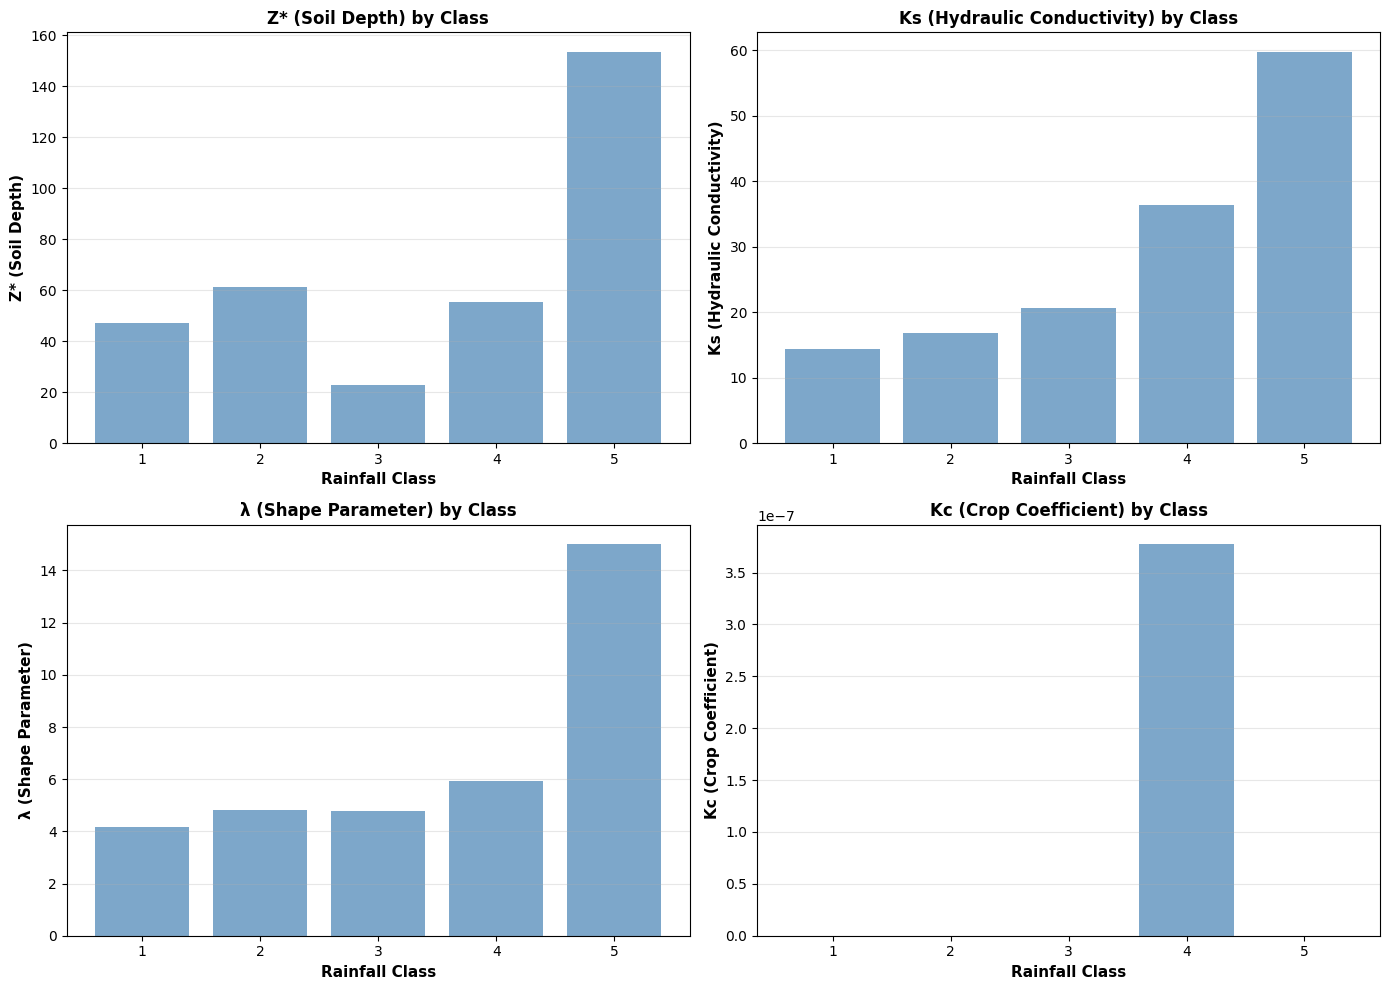


Plot saved to: G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana\parameter_variation_by_class.png


In [13]:
if len(summary_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot each parameter
    params = ['Zstar', 'Ks', 'lambda', 'Kc']
    titles = ['Z* (Soil Depth)', 'Ks (Hydraulic Conductivity)', 
              'λ (Shape Parameter)', 'Kc (Crop Coefficient)']
    
    for i, (param, title) in enumerate(zip(params, titles)):
        ax = axes[i // 2, i % 2]
        ax.bar(summary_df['Class'], summary_df[param], color='steelblue', alpha=0.7)
        ax.set_xlabel('Rainfall Class', fontsize=11, fontweight='bold')
        ax.set_ylabel(title, fontsize=11, fontweight='bold')
        ax.set_title(f'{title} by Class', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticks(summary_df['Class'])
    
    plt.tight_layout()
    plot_file = OUTPUT_DIR / 'parameter_variation_by_class.png'
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nPlot saved to: {plot_file}")
else:
    print("No data to plot.")


## 12. Plot RMSE Comparison

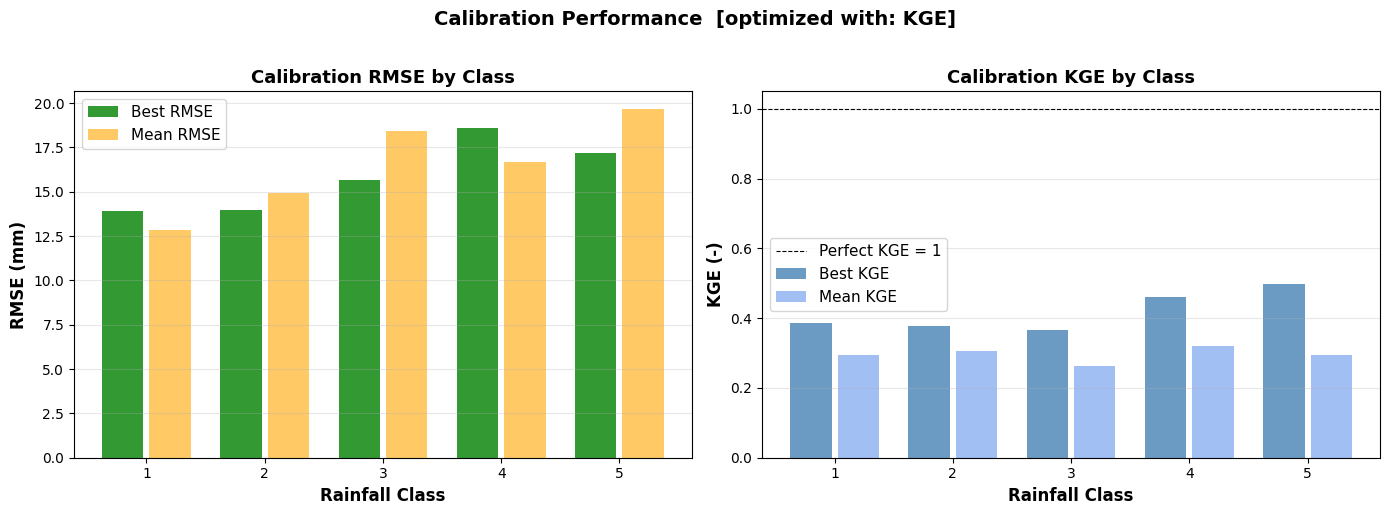


Performance plot saved to: G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana\rmse_kge_comparison_by_class.png


In [14]:

if len(summary_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    x = summary_df['Class']
    
    # --- RMSE subplot ---
    ax = axes[0]
    ax.bar(x - 0.2, summary_df['Best_RMSE'], width=0.35, alpha=0.8, label='Best RMSE',  color='green')
    ax.bar(x + 0.2, summary_df['Mean_RMSE'], width=0.35, alpha=0.6, label='Mean RMSE',  color='orange')
    ax.set_xlabel('Rainfall Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('RMSE (mm)', fontsize=12, fontweight='bold')
    ax.set_title('Calibration RMSE by Class', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks(x)
    
    # --- KGE subplot ---
    ax = axes[1]
    ax.bar(x - 0.2, summary_df['Best_KGE'], width=0.35, alpha=0.8, label='Best KGE',  color='steelblue')
    ax.bar(x + 0.2, summary_df['Mean_KGE'], width=0.35, alpha=0.6, label='Mean KGE',  color='cornflowerblue')
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, label='Perfect KGE = 1')
    ax.set_xlabel('Rainfall Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('KGE (-)', fontsize=12, fontweight='bold')
    ax.set_title('Calibration KGE by Class', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks(x)
    
    plt.suptitle(f'Calibration Performance  [optimized with: {OBJECTIVE_FUNCTION}]',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    rmse_plot_file = OUTPUT_DIR / 'rmse_kge_comparison_by_class.png'
    plt.savefig(rmse_plot_file, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nPerformance plot saved to: {rmse_plot_file}")
else:
    print("No data to plot.")


## Completion Summary

This notebook has:
1. ✓ Loaded SMAP soil moisture data from NetCDF
2. ✓ Read rainfall classification for SMAP grid points
3. ✓ Loaded filtered calibration dates for each class
4. ✓ Resampled temperature and precipitation to SMAP grid using nearest neighbor
5. ✓ Calibrated 4 SM2RAIN parameters (Z*, Ks, λ, Kc) for each class
6. ✓ Saved results to JSON files (one per class)
7. ✓ Printed best parameters for each class
8. ✓ Created visualization plots

**Output Files:**
- `class_{i}_calibration_results.json` - Detailed results for each class
- `all_classes_calibration_results.json` - Combined results
- `all_classes_best_parameters.csv` - Summary table
- `parameter_variation_by_class.png` - Parameter plots
- `rmse_comparison_by_class.png` - RMSE comparison